In [46]:
# run in a cell (you may need to install gmsh and meshio if not present)
# !pip install gmsh==4.11.0 meshio scipy matplotlib numpy

import gmsh
import meshio
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

# nicer plotting defaults
plt.rcParams.update({'figure.figsize': (8,6), 'font.size': 12})


In [47]:
# Parameters (example geometry -- modify to your cavity)
# We'll create a rectangular cavity  length (along z) x radius (along r)
length = 0.1   # meters (z-direction)
radius = 0.15   # meters (r-direction)
mesh_size = radius/50  # target element size
c = 299792458.0

In [48]:
# Analytical TM010 frequency for a pillbox cavity

x01 = 2.4048255577  # first zero of J0
f_tm010 = c * x01 / (2*np.pi*radius)
f_tm010/1e6

764.9501855694117

In [ ]:
# Initialize gmsh
gmsh.initialize()
gmsh.model.add("axisymmetric_cavity")


# Points (z, r)
p1 = gmsh.model.geo.addPoint(0.0, 0.0, 0, mesh_size)   # axis corner (z=0,r=0)
p2 = gmsh.model.geo.addPoint(length, 0.0, 0, mesh_size) # axis top (z=length,r=0)
p3 = gmsh.model.geo.addPoint(length, radius, 0, mesh_size)
p4 = gmsh.model.geo.addPoint(0.0, radius, 0, mesh_size)

# Lines (edges of the 2D profile)
l1 = gmsh.model.geo.addLine(p1, p2)  # axis line (r=0)
l2 = gmsh.model.geo.addLine(p2, p3)
l3 = gmsh.model.geo.addLine(p3, p4)
l4 = gmsh.model.geo.addLine(p4, p1)

# Curve loop and plane surface
cl = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4])
surf = gmsh.model.geo.addPlaneSurface([cl])

# Physical groups (for BCs)
gmsh.model.geo.addPhysicalGroup(1, [l1], tag=1)  # axis line
gmsh.model.geo.addPhysicalGroup(1, [l2, l3, l4], tag=2)  # cavity walls
gmsh.model.geo.addPhysicalGroup(2, [surf], tag=3)  # interior surface

# Synchronize and mesh
gmsh.model.geo.synchronize()
gmsh.model.mesh.generate(2)

# write mesh to file for meshio to read
msh_filename = "cavity.msh"
gmsh.write(msh_filename)
gmsh.finalize()

# read with meshio

mesh = meshio.read(msh_filename)

# Extract points and triangular cells
points = mesh.points[:, :2]   # (x,y) but represents (z,r)
cells = None
for cell_block in mesh.cells:
    if cell_block.type == "triangle":
        cells = cell_block.data
        break


if cells is None:
    raise RuntimeError("No triangular cells found in mesh.")

print("Nodes:", points.shape[0], "Triangles:", cells.shape[0])


radius = np.max(points[:,1])  # max r value from points
L = np.max(points[:,0])       # max z value from points

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000126584s, CPU 0.000199s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.02382s, CPU 0.02239s)
Info    : 2064 nodes 4130 elements
Info    : Writing 'cavity.msh'...
Info    : Done writing 'cavity.msh'

Nodes: 2064 Triangles: 3958


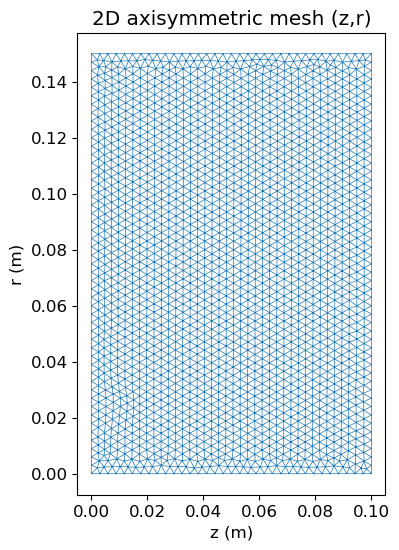

In [50]:
# quick mesh plot
plt.triplot(points[:,0], points[:,1], cells, lw=0.5)
plt.gca().set_aspect('equal')
plt.xlabel('z (m)')
plt.ylabel('r (m)')
plt.title('2D axisymmetric mesh (z,r)')
plt.show()


In [51]:
# Helper: assemble element stiffness and mass for a triangle
def triangle_matrices(coords):
    # coords: 3x2 array of node coordinates [[z1,r1],[z2,r2],[z3,r3]]
    x1,y1 = coords[0]; x2,y2 = coords[1]; x3,y3 = coords[2]
    # area
    det = (x2-x1)*(y3-y1) - (x3-x1)*(y2-y1)
    area = 0.5 * abs(det)
    if area <= 0:
        return None, None

    # Gradients of barycentric shape functions:
    # phi_i has gradient grad phi_i = [dphi/dx, dphi/dy]
    # Using formula from linear triangle
    B = np.zeros((3,2))
    # compute coefficients for shape function gradients (standard)
    # grad phi1 = [(y2 - y3), (x3 - x2)] / det*? careful with sign
    # We'll compute using solving linear system: phi = a + b x + c y; phi=1 at node i
    A_mat = np.array([[1, x1, y1],
                      [1, x2, y2],
                      [1, x3, y3]])
    grads = np.zeros((3,2))
    for i in range(3):
        rhs = np.zeros(3); rhs[i] = 1.0
        # solve for coefficients [a, b, c] with A_mat @ [a,b,c] = rhs
        a_b_c = np.linalg.solve(A_mat, rhs)
        grads[i,:] = a_b_c[1:]   # b,c are derivatives w.r.t x,y

    # local stiffness ke_ij = ∫ (grad phi_i . grad phi_j) * r * dA
    # local mass me_ij = ∫ phi_i * phi_j * r * dA
    # approximate r by centroid r_c
    r_c = (y1 + y2 + y3) / 3.0

    ke = np.zeros((3,3))
    me = np.zeros((3,3))

    for i in range(3):
        for j in range(3):
            ke[i,j] = (grads[i].dot(grads[j])) * (r_c * area)
            # mass for linear triangle: ∫ phi_i phi_j dA -> area * (1/12) if i!=j, area*(1/6) if i==j
            me[i,j] = (area * r_c) * (1.0/12.0 if i != j else 1.0/6.0)

    return ke, me

# Build sparse matrices
n_nodes = points.shape[0]
row = []
col = []
data_A = []
data_M = []

for tri in cells:
    coords = points[tri]   # 3x2
    ke, me = triangle_matrices(coords)
    if ke is None:
        continue
    for a in range(3):
        for b in range(3):
            row.append(tri[a])
            col.append(tri[b])
            data_A.append(ke[a,b])
            data_M.append(me[a,b])

A = sp.coo_matrix((data_A, (row, col)), shape=(n_nodes, n_nodes)).tocsr()
M = sp.coo_matrix((data_M, (row, col)), shape=(n_nodes, n_nodes)).tocsr()

print("Assembled matrices: A shape", A.shape, "nnz", A.nnz, " ; M nnz", M.nnz)


Assembled matrices: A shape (2064, 2064) nnz 14106  ; M nnz 14106


In [52]:
# find boundary nodes approximately
tol = mesh_size * 0.2
z = points[:,0]; r = points[:,1]
on_axis = np.isclose(r, 0.0, atol=tol)
on_r_outer = np.isclose(r, radius, atol=tol)
on_z0 = np.isclose(z, 0.0, atol=tol)
on_zL = np.isclose(z, length, atol=tol)

# For the pillbox TM benchmark we solve directly for E_z.
# Boundary conditions are:
#   - E_z = 0 on the cylindrical wall r = R
#   - dE_z/dz = 0 on the end caps z = 0 and z = L
# So only the outer radial wall is Dirichlet here.
dirichlet_nodes = np.where(on_r_outer)[0]

print("Dirichlet nodes (count):", dirichlet_nodes.size)

free_nodes = np.setdiff1d(np.arange(n_nodes), dirichlet_nodes)
A_free = A[free_nodes][:, free_nodes]
M_free = M[free_nodes][:, free_nodes]

print("Free nodes (count):", free_nodes.size)


Dirichlet nodes (count): 35
Free nodes (count): 2029


In [53]:
k_eigs = 12  # number of eigenvalues to compute

# Solve the reduced generalized eigenproblem A E = lambda M E.
# With the TM pillbox boundary conditions above, the lowest mode should be TM010.
vals_red, vecs_red = spla.eigsh(A_free, k=min(k_eigs, A_free.shape[0]-2), M=M_free, sigma=0.0, which='LM', tol=1e-9)

idx = np.argsort(np.real(vals_red))
vals = np.maximum(np.real(vals_red[idx]), 0.0)
vecs_red = np.real(vecs_red[:, idx])

ks = np.sqrt(vals)
freqs = ks * c / (2*np.pi)

# Map the reduced eigenvectors back onto the full node set.
vecs = np.zeros((n_nodes, vecs_red.shape[1]))
vecs[free_nodes, :] = vecs_red

print("Analytical TM010 frequency (MHz):", f_tm010/1e6)
print("Computed frequencies (MHz):", freqs/1e6)
print("Lowest-mode relative error (%):", 100.0 * abs(freqs[0] - f_tm010) / f_tm010)


Analytical TM010 frequency (MHz): 764.9501855694117
Computed frequencies (MHz): [ 764.9133057  1683.35754442 1756.08661374 2309.75894868 2754.11475281
 3097.429453   3137.03959885 3478.94074208 3755.18944013 4045.27316199
 4077.1383958  4572.76997454]
Lowest-mode relative error (%): 0.0048212117037153435


In [54]:
vecs_refined = [vecs[:, i] for i in range(vecs.shape[1])]
ks_refined = [ks[i] for i in range(len(ks))]
freqs_refined = [freqs[i] for i in range(len(freqs))]


In [55]:
np.shape(vecs_refined)

(12, 2064)

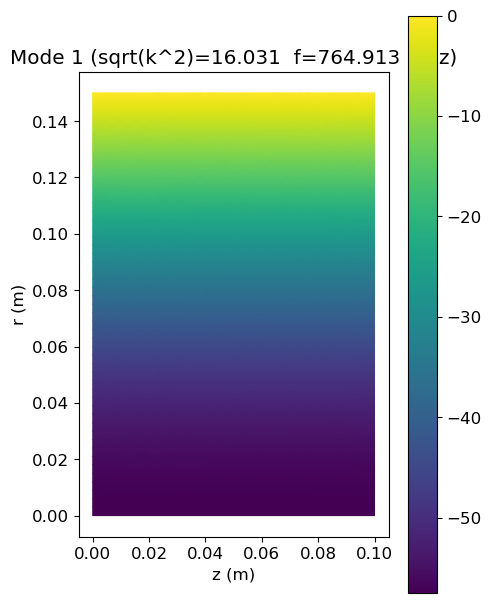

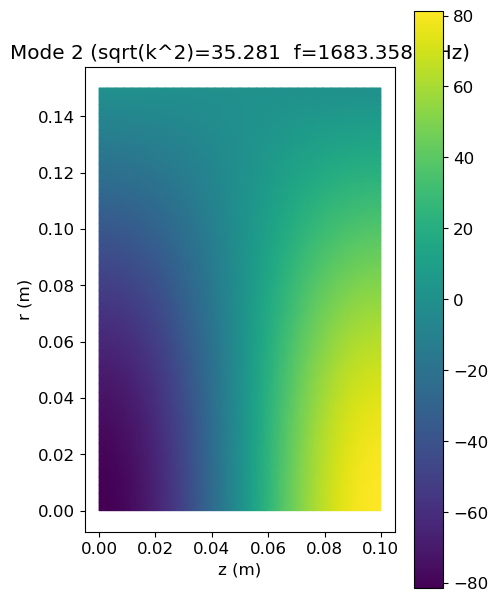

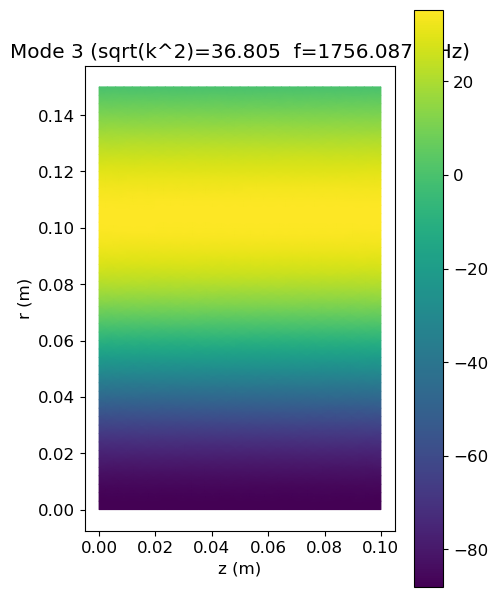

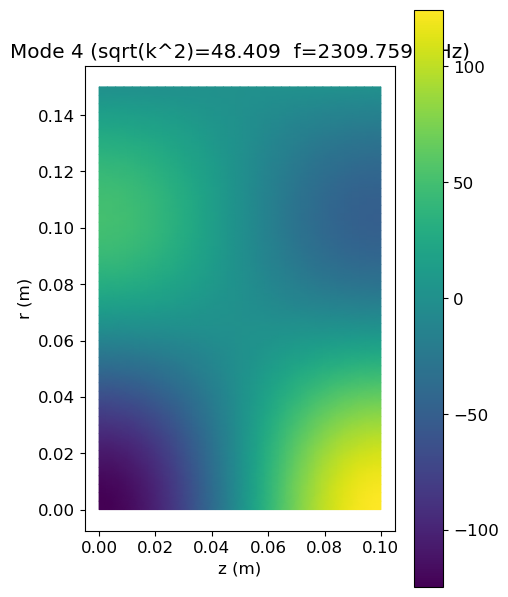

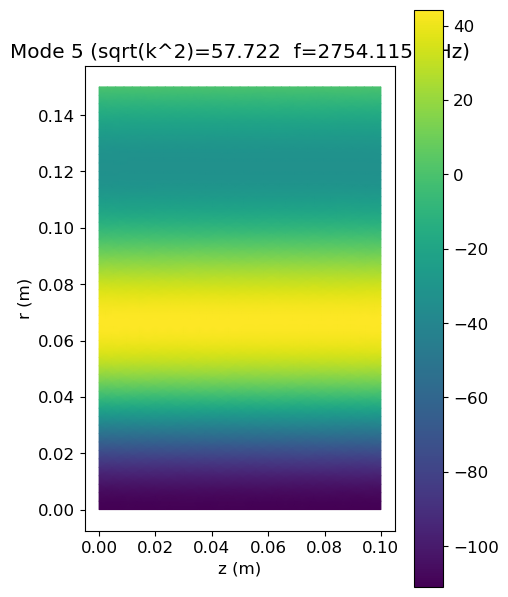

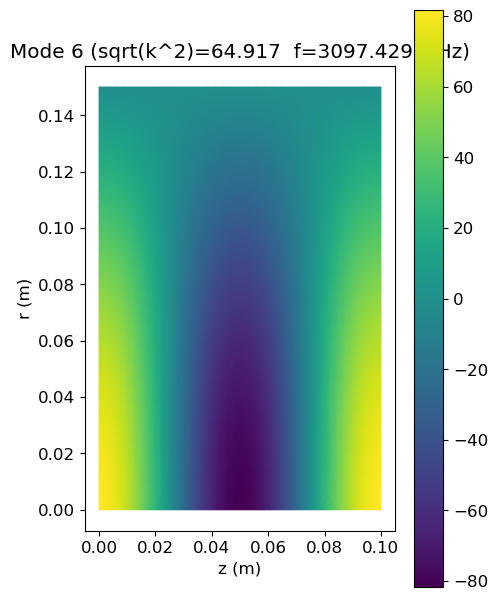

In [56]:
from matplotlib.tri import Triangulation, TriAnalyzer, UniformTriRefiner

triang = Triangulation(points[:,0], points[:,1], cells)
n_plot = min(6, vecs.shape[1])

for i in range(n_plot):
    mode = vecs_refined[i]
    # mask nodes that were Dirichlet to zero (should already be)
    mode_vis = mode.real
    plt.figure(figsize=(50*length,50*radius))
    tpc = plt.tripcolor(triang, mode_vis, shading='gouraud')
    plt.colorbar(tpc)
    plt.gca().set_aspect('equal')
    plt.title(f"Mode {i+1} (sqrt(k^2)={ks_refined[i]:.3f}  f={freqs_refined[i]/1e6:.3f} MHz)")
    plt.xlabel("z (m)")
    plt.ylabel("r (m)")
    plt.show()


In [57]:

# Physical constant
eps0 = 8.8541878128e-12  # vacuum permittivity, F/m

# choose mode index to use (0-based). For the pillbox benchmark,
# the lowest computed mode should be TM010.
mode_index = 3

# The eigenvector is E_z directly in this formulation.
Ez_nodes = vecs_refined[mode_index].astype(np.complex128)
if np.mean(Ez_nodes[on_axis].real) < 0:
    Ez_nodes *= -1.0

print("Selected mode frequency (MHz):", freqs_refined[mode_index] / 1e6)
print("Analytical TM010 frequency (MHz):", f_tm010 / 1e6)


Selected mode frequency (MHz): 2309.758948684796
Analytical TM010 frequency (MHz): 764.9501855694117


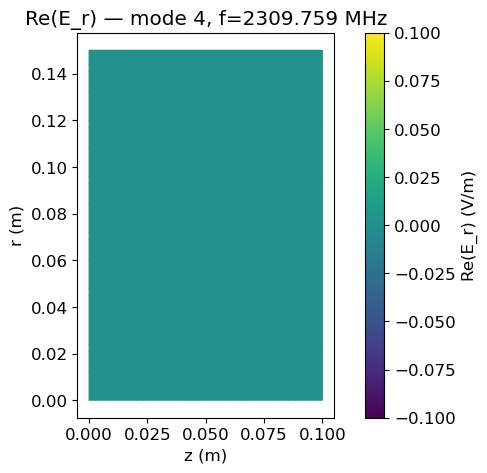

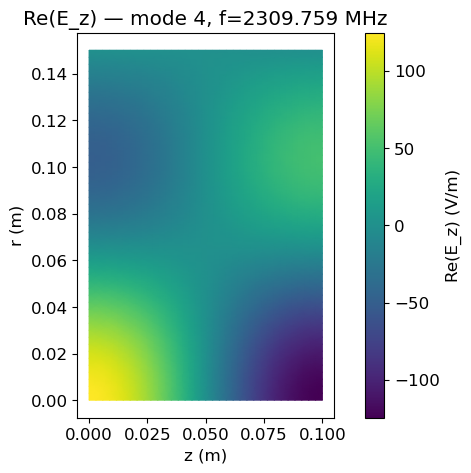

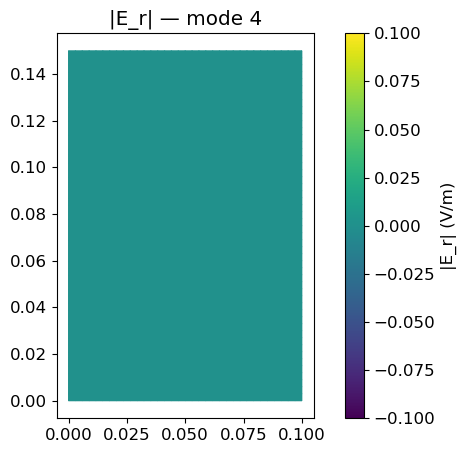

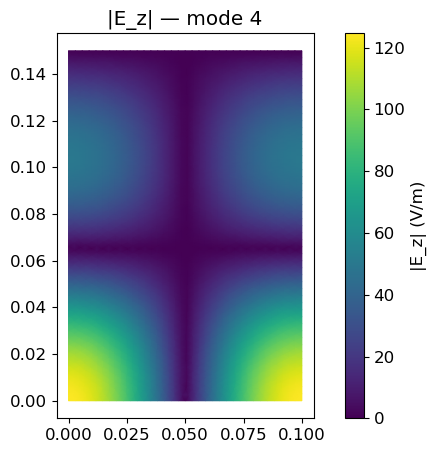

In [58]:
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation

# In this pillbox benchmark notebook we solved directly for E_z.
# For TM010, E_z is approximately uniform in z and E_r is ideally zero.
z_nodes = points[:,0]
r_nodes = points[:,1]
omega = 2*np.pi * freqs_refined[mode_index]

E_z_nodes = Ez_nodes
E_r_nodes = np.zeros_like(E_z_nodes)

# For visualization, use the real field shape.
E_r_real = E_r_nodes.real
E_z_real = E_z_nodes.real
E_r_abs = np.abs(E_r_nodes)
E_z_abs = np.abs(E_z_nodes)

# prepare triangulation
triang = Triangulation(points[:,0], points[:,1], cells)

# Plot real(E_r)
plt.figure(figsize=(8,5))
tpc = plt.tripcolor(triang, E_r_real, shading='gouraud')
plt.colorbar(tpc, label='Re(E_r) (V/m)')
plt.title(f"Re(E_r) — mode {mode_index+1}, f={freqs_refined[mode_index]/1e6:.3f} MHz")
plt.xlabel('z (m)')
plt.ylabel('r (m)')
plt.gca().set_aspect('equal')
plt.show()

# Plot real(E_z)
plt.figure(figsize=(8,5))
tpc = plt.tripcolor(triang, E_z_real, shading='gouraud')
plt.colorbar(tpc, label='Re(E_z) (V/m)')
plt.title(f"Re(E_z) — mode {mode_index+1}, f={freqs_refined[mode_index]/1e6:.3f} MHz")
plt.xlabel('z (m)')
plt.ylabel('r (m)')
plt.gca().set_aspect('equal')
plt.show()

# Plot magnitudes
plt.figure(figsize=(8,5))
tpc = plt.tripcolor(triang, E_r_abs, shading='gouraud')
plt.colorbar(tpc, label='|E_r| (V/m)')
plt.title(f"|E_r| — mode {mode_index+1}")
plt.gca().set_aspect('equal')
plt.show()

plt.figure(figsize=(8,5))
tpc = plt.tripcolor(triang, E_z_abs, shading='gouraud')
plt.colorbar(tpc, label='|E_z| (V/m)')
plt.title(f"|E_z| — mode {mode_index+1}")
plt.gca().set_aspect('equal')
plt.show()


In [59]:

from matplotlib.tri import Triangulation, LinearTriInterpolator

# Use real part for instantaneous field
Ez_plot = E_z_nodes.real
Er_plot = E_r_nodes.real

triang = Triangulation(points[:,0], points[:,1], cells)

interp_Ez = LinearTriInterpolator(triang, Ez_plot)
interp_Er = LinearTriInterpolator(triang, Er_plot)

# Regular grid
nz = 300
nr = 300

z_min, z_max = points[:,0].min(), points[:,0].max()
r_min, r_max = points[:,1].min(), points[:,1].max()

z_grid = np.linspace(z_min, z_max, nz)
r_grid = np.linspace(r_min, r_max, nr)

Z, R = np.meshgrid(z_grid, r_grid)

Ez_grid = interp_Ez(Z, R)
Er_grid = interp_Er(Z, R)

# Mask outside mesh
mask = np.isnan(Ez_grid)
Ez_grid = np.ma.array(Ez_grid, mask=mask)
Er_grid = np.ma.array(Er_grid, mask=mask)


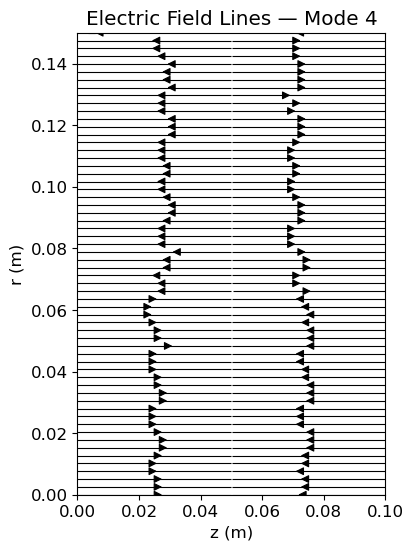

In [60]:
plt.figure(figsize=(8,6))

plt.streamplot(
    z_grid,
    r_grid,
    Ez_grid,
    Er_grid,
    density=2.0,        # increase for more lines
    linewidth=0.8,
    arrowsize=1.2,
    color='black'
)

plt.title(f"Electric Field Lines — Mode {mode_index+1}")
plt.xlabel("z (m)")
plt.ylabel("r (m)")
plt.gca().set_aspect('equal')

plt.xlim(z_min, z_max)
plt.ylim(r_min, r_max)

plt.show()
